<a href="https://colab.research.google.com/github/Mogu-code/DataScience/blob/main/FDS_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

==# !pip install --upgrade pandas
!pip install duckdb

In [ ]:
!pip install --upgrade duckdb pandas #to upgrade

In [ ]:
import numpy as np
import pandas as pd
import duckdb

# This does 2 steps:

# 1️⃣ duckdb.sql(query)
# → executes SQL query

# 2️⃣ .df()
# → converts SQL result into Pandas dataframe

def sqldf(query): #Creates a function named sqldf
    # run sql on pandas dataframe in scope using duckdb. return result as dataframe
    return duckdb.sql(query).df()

In [ ]:
data = {
    "name": ["A", "B", "C"],
    "marks": [90, 80, 85]
}

df = pd.DataFrame(data)

duckdb.sql("SELECT * FROM df")

┌─────────┬───────┐
│  name   │ marks │
│ varchar │ int64 │
├─────────┼───────┤
│ A       │    90 │
│ B       │    80 │
│ C       │    85 │
└─────────┴───────┘

In [ ]:
df
duckdb.sql("SELECT * FROM df").df()

,name,marks
0,A,90
1,B,80
2,C,85


# STARTING SQL
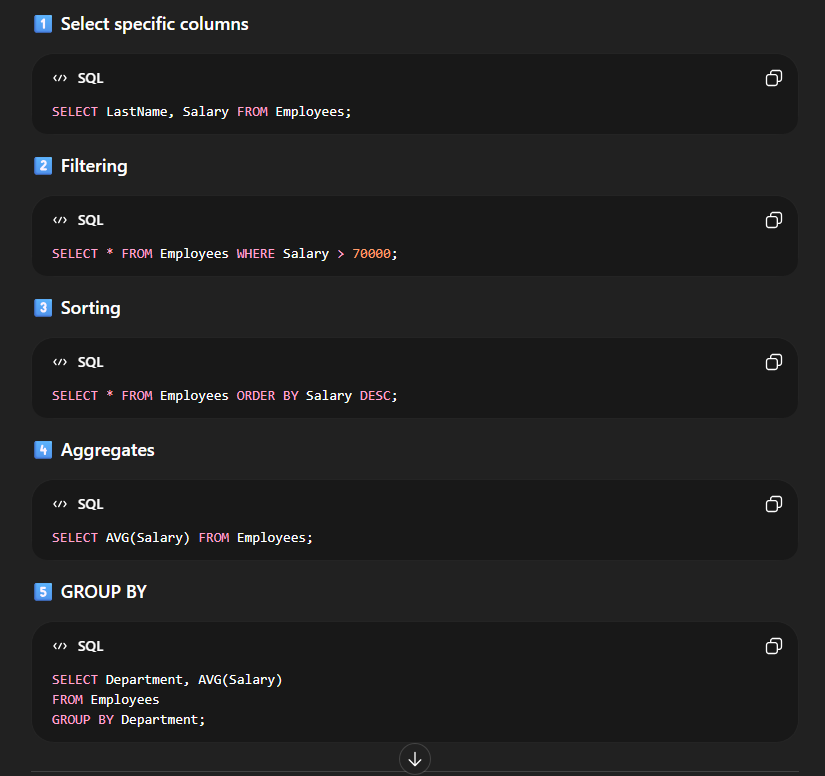

In [ ]:
data = {
    'EmployeeID': [101, 102, 103, 104, 105, 106, 107],
'LastName': ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller'],
 'Department': ['Sales', 'IT', 'Marketing', 'Sales', 'HR', None, 'IT'],
 'Salary': [65000.00, 95000.00, 55000.00, 72000.00, 80000.00, 48000.00, 110000.00],
 'HireDate': ['2023-01-15', '2024-06-01', '2023-08-20', '2023-10-10', '2024-03-05', '2022-11-22', '2025-01-01']
}
Employees=pd.DataFrame(data)
print(Employees)

   EmployeeID  LastName Department    Salary    HireDate
0         101     Smith      Sales   65000.0  2023-01-15
1         102   Johnson         IT   95000.0  2024-06-01
2         103  Williams  Marketing   55000.0  2023-08-20
3         104     Brown      Sales   72000.0  2023-10-10
4         105     Jones         HR   80000.0  2024-03-05
5         106    Garcia        NaN   48000.0  2022-11-22
6         107    Miller         IT  110000.0  2025-01-01


In [ ]:
#Give me all columns and all rows from Employees”
sql_query= """
SELECT *
FROM Employees;
"""

In [ ]:
Employees = pd.DataFrame(data)
result_df=sqldf(sql_query) #runs on the helper function we used earlier we passed the query as parameter and converted it to dataframe DuckDB:

# 1️⃣ Sees dataframe named Employees
# 2️⃣ Treats it like a SQL table
# 3️⃣ Executes query
# 4️⃣ Returns result as dataframe
print(result_df)

   EmployeeID  LastName Department    Salary    HireDate
0         101     Smith      Sales   65000.0  2023-01-15
1         102   Johnson         IT   95000.0  2024-06-01
2         103  Williams  Marketing   55000.0  2023-08-20
3         104     Brown      Sales   72000.0  2023-10-10
4         105     Jones         HR   80000.0  2024-03-05
5         106    Garcia        NaN   48000.0  2022-11-22
6         107    Miller         IT  110000.0  2025-01-01


In [ ]:
sql_query="""
SELECT EmployeeID,Salary
FROM Employees;
"""
result=sqldf(sql_query)
print(result)

   EmployeeID    Salary
0         101   65000.0
1         102   95000.0
2         103   55000.0
3         104   72000.0
4         105   80000.0
5         106   48000.0
6         107  110000.0


In [ ]:
sql_query1="""
SELECT LastName,Department,HireDate
FROM Employees
WHERE Department='HR' OR HireDate>'2024-06-01';
"""
result1=sqldf(sql_query1)
print(result1)

  LastName Department    HireDate
0    Jones         HR  2024-03-05
1   Miller         IT  2025-01-01


# LIKE(PATTERN MATCHING)
PURPOSE- FPR SEARCHING SPECIFIED PATTWE ON TEXT/COLUM, USES WILDCARD\
%- represents 0,1,multiple chars\
_(underscore)- exactly 1 single chars

In [ ]:
sql_query="""
SELECT LastName,Department,Salary
FROM Employees
WHERE LastName LIKE 'J%' OR Department='Marketing';
"""
result=sqldf(sql_query)
print("Pattern match or missing data (like,or,is)")
print(result)

Pattern match or missing data (like,or,is)
   LastName Department   Salary
0   Johnson         IT  95000.0
1  Williams  Marketing  55000.0
2     Jones         HR  80000.0


# Data **wrungling**
JOIN other_table ON condition -- (Optional Combine with other data\
WHERE condition -- (Optional) Filter individual rows\
GROUP BY column_name(s) -- (Optional) Aggregate data (sum, avg, count)\
HAVING condition -- (Optional) Filter groups (used with GROUP BY)\
ORDER BY column_name(s) -- (Optional) Sort the final results\
LIMIT n; -- (Optional) Return only the first n rows

FROM / JOIN: The database identifies the total "universe" of data.\
WHERE: It filters out rows that don't meet your criteria. 1\
GROUP BY: It collapses the remaining rows into groups.\
HAVING: It filters the groups (e.g., "only show categories with more than 10 sales?\
SELECT: Only now does the database "see" the columns you asked for and calcu\
ORDER BY: It sorts the final, filtered, and aggregated list.

In [ ]:
import pandas as pd
import duckdb as db
data = {
 'CustomerID': [1, 2, 3, 4, 5],
 'Name': [' alice  ', 'BOB SMITH', 'Charlie.D', 'dave ', 'eve '],
 'ProductCode': ['A-101-L', 'b-202-XL', 'C-303-S',
 'A-101-M ', 'D-404-M'],
 'Email': [' aLice@mail.com', 'BOB@work.net ', 'charLIE@web.io ',
 'dave@corp.co ', 'eve@home.net']
}
CustomerData=pd.DataFrame(data)
print(CustomerData)

   CustomerID       Name ProductCode            Email
0           1    alice       A-101-L   aLice@mail.com
1           2  BOB SMITH    b-202-XL    BOB@work.net 
2           3  Charlie.D     C-303-S  charLIE@web.io 
3           4      dave     A-101-M     dave@corp.co 
4           5       eve      D-404-M     eve@home.net


applt TRIM to remove leading/trailing spaces,\
 then UPPERCASE for the name\
convert email address to lowercase

standardize all name to upper case\
clean extra spaces by TRIM\
convert email to lowercase

In [ ]:
sql_mungling_1="""
SELECT
CustomerID,UPPER(TRIM(Name)) AS Standardized_Name,
LOWER(Email) AS Cleaned_Email
FROM CustomerData;
"""
df_standardized=sqldf(sql_mungling_1)
print("UPPER,LOWER,TRIM")
print(df_standardized)

UPPER,LOWER,TRIM
   CustomerID Standardized_Name    Cleaned_Email
0           1             ALICE   alice@mail.com
1           2         BOB SMITH    bob@work.net 
2           3         CHARLIE.D  charlie@web.io 
3           4              DAVE    dave@corp.co 
4           5               EVE     eve@home.net


# LTRIM -REMOVE LEADING SPACES
# RTRIM- REMOVE TRAILING SPACES

In [ ]:
#REMOVE ONLY SPACES FROM RIGHT SIDE OF NAME
#REMOVE ONLY SPACES FROM LEFT SIDE OF EMAIL
sql_mungling_2="""
SELECT
CustomerID,
RTRIM(Name) AS Right_Trimmed_Name,
LTRIM(Email) AS Left_Trimmed_Email
FROM CustomerData;
"""

df_ltrim=sqldf(sql_mungling_2)
print(df_ltrim)


   CustomerID Right_Trimmed_Name Left_Trimmed_Email
0           1              alice     aLice@mail.com
1           2          BOB SMITH      BOB@work.net 
2           3          Charlie.D    charLIE@web.io 
3           4               dave      dave@corp.co 
4           5                eve       eve@home.net


# REPLACE

In [ ]:
#REPLACE single l with status xl
sql_mungling_3="""
SELECT
CustomerID,
ProductCode,
REPLACE(
  REPLACE(ProductCode,'L','XL'),
  '-','') AS Cleaned_ProductCode
FROM CustomerData;
"""
df_replace=sqldf(sql_mungling_3)
print(df_replace)

   CustomerID ProductCode Cleaned_ProductCode
0           1     A-101-L              A101XL
1           2    b-202-XL             b202XXL
2           3     C-303-S               C303S
3           4    A-101-M               A101M 
4           5     D-404-M               D404M


In [ ]:
import duckdb
sql_mungling_4="""
SELECT
CustomerID,
ProductCode,
LEFT(ProductCode,3) AS Item_Type_Prefix,
RIGHT(Email,4) AS Domain_Suffix
FROM CustomerData;
"""
df_sub_string=sqldf(sql_mungling_4)
(df_sub_string)

#

,CustomerID,ProductCode,Item_Type_Prefix,Domain_Suffix
0,1,A-101-L,A-1,.com
1,2,b-202-XL,b-2,net
2,3,C-303-S,C-3,.io
3,4,A-101-M,A-1,.co
4,5,D-404-M,D-4,.net


# SUBSTR

In [ ]:
#there are also different ways of indexing, select last 4 and select from 1 to index 3
sql_mungling_4_corrected="""
SELECT
CustomerID,
ProductCode,
Email,
SUBSTR(ProductCode,1,3) AS Item_Type_Prefix,
SUBSTR(Email,-4) AS Domain_Suffix
FROM CustomerData;
"""
df_sub_string_corrected=sqldf(sql_mungling_4_corrected)
print(df_sub_string_corrected)


   CustomerID ProductCode            Email Item_Type_Prefix Domain_Suffix
0           1     A-101-L   aLice@mail.com              A-1          .com
1           2    b-202-XL    BOB@work.net               b-2          net 
2           3     C-303-S  charLIE@web.io               C-3          .io 
3           4    A-101-M     dave@corp.co               A-1          .co 
4           5     D-404-M     eve@home.net              D-4          .net


In [ ]:
data={
    'city':['New York','Los Angeles','Chicago','Houston','Miami'],
    'sales':[100,150,120,90,80],
}
df=pd.DataFrame(data)
print(df)

          city  sales
0     New York    100
1  Los Angeles    150
2      Chicago    120
3      Houston     90
4        Miami     80


# GROUP BY ORDER BY

In [ ]:
#defining simple sql query
sql_query="""
SELECT city,SUM(sales) AS total_sales,
FROM df
GROUP BY city,
ORDER BY total_sales DESC;
"""
result_df=sqldf(sql_query)
print(result_df)

          city  total_sales
0  Los Angeles        150.0
1      Chicago        120.0
2     New York        100.0
3      Houston         90.0
4        Miami         80.0


In [ ]:
from os import ST_APPEND
#import pandas as pd
import duckdb

students_df=pd.DataFrame({
    'student_id':[1,2,3,4,5],
    'name':['Zoe','Liam','Noah','Ema','Tina'],
    'score':[85,92,78,95,88]
})
students_df

,student_id,name,score
0,1,Zoe,85
1,2,Liam,92
2,3,Noah,78
3,4,Ema,95
4,5,Tina,88


In [ ]:
sql_query="""
SELECT
name,
score,
CASE
  WHEN score >=90 THEN 'A'
  WHEN score >=80 THEN 'B'
  WHEN score>=70 THEN 'C'
  WHEN score>=60 THEN 'D'
  ELSE 'F'
  END AS letter_grade,
  CASE
  WHEN score >=60 THEN 'PASS'
  ELSE 'FAIL'
  END AS status
FROM students_df;
"""
result_df=sqldf(sql_query)
print(result_df)

   name  score letter_grade status
0   Zoe     85            B   PASS
1  Liam     92            A   PASS
2  Noah     78            C   PASS
3   Ema     95            A   PASS
4  Tina     88            B   PASS


In [ ]:
import numpy as np
import pandas as pd
import duckdb

def sqldf(query):
    return duckdb.sql(query).df()


data={
    'product':['Laptop','Mouse','Monitor','Keyboard'],
    'sale_price':[1200,None,300, None],
    'suggested_price':[1150,25,None,70],
    'default_price':[1000,20,250,50]
      }

df=pd.DataFrame(data)

sql_query1="""SELECT * FROM df;"""
print(sqldf(sql_query1))

    product  sale_price  suggested_price  default_price
0    Laptop      1200.0           1150.0           1000
1     Mouse         NaN             25.0             20
2   Monitor       300.0              NaN            250
3  Keyboard         NaN             70.0             50


In [ ]:
sql_query2="""SELECT product, sale_price,suggested_price,COALESCE(sale_price,suggested_price) AS final_price FROM df;"""

print(sqldf(sql_query2))

    product  sale_price  suggested_price  final_price
0    Laptop      1200.0           1150.0       1200.0
1     Mouse         NaN             25.0         25.0
2   Monitor       300.0              NaN        300.0
3  Keyboard         NaN             70.0         70.0


In [ ]:
# sql_query3="""SELECT
#           --1.Prevent division by zero if units_sold is 0,make NULL revenue/ nullif (units_sold,0) AS price_per_unit
#           --2. Clean empty strings:if category is '', make it NULL
#           NULLIF (category,'') AS cleaned_category
#           FROM df ;
#           """
# print(sqldf(sql_query3))
sql_query3="""
SELECT
product,
NULLIF(sale_price, 0) AS cleaned_sale_price
FROM df;
"""
print(sqldf(sql_query3))

    product  cleaned_sale_price
0    Laptop              1200.0
1     Mouse                 NaN
2   Monitor               300.0
3  Keyboard                 NaN


inner join, outer join,left(4 types)

inner **join**
returns only rows where there is a match in both tables

In [ ]:
import pandas as pd
import duckdb
#left table
employees=pd.DataFrame({
    'employee_id':[1,2,3,4],
    'name':['Alice','Bob','Charlie','David'],
    'department_id':[10,20,30,40] #DAVID IS IN DEPT 40
})
#right table
departments=pd.DataFrame({
    'department_id':[10,20,30],
    'department_name':['HR','IT','Marketing']
})

In [ ]:
print("### Employees Table ###")
print(employees)
print("\n### Departments Table ###")
print(departments)

### Employees Table ###
   employee_id     name  department_id
0            1    Alice             10
1            2      Bob             20
2            3  Charlie             30
3            4    David             40

### Departments Table ###
   department_id department_name
0             10              HR
1             20              IT
2             30       Marketing


In [ ]:
inner_query="""
SELECT *
FROM employees e
INNER JOIN departments d ON e.department_id=d.department_id;
"""
print(sqldf(inner_query))

   employee_id     name  department_id  department_id_1 department_name
0            1    Alice             10               10              HR
1            2      Bob             20               20              IT
2            3  Charlie             30               30       Marketing


In [ ]:
inner_query="""
SELECT e.name,d.department_name
FROM employees e
INNER JOIN departments d ON e.department_id=d.department_id;
"""
print(sqldf(inner_query))

      name department_name
0    Alice              HR
1      Bob              IT
2  Charlie       Marketing


LEFT JOIN
1.   RETURNS ALL ROWS FROM LEFT TABLE AND MATCHED ROWS FROM RIGHT TABLE
2.   IF NO MATCH, RESULT IS NAN


In [ ]:
left_query="""
SELECT *
FROM employees e
LEFT JOIN departments d ON e.department_id=d.department_id;
"""
print(duckdb.query(left_query).to_df())


   employee_id     name  department_id  department_id_1 department_name
0            1    Alice             10               10              HR
1            2      Bob             20               20              IT
2            3  Charlie             30               30       Marketing
3            4    David             40             <NA>             NaN


right join

In [ ]:
right_query="""
SELECT e.name,d.department_name
FROM employees e
RIGHT JOIN departments d ON e.department_id=d.department_id;
"""

OUTER JOIN

In [ ]:
full_query="""
SELECT *
FROM employees e
FULL OUTER JOIN departments d ON e.department_id=d.department_id;
"""
print(duckdb.query(full_query).to_df())

   employee_id     name  department_id  department_id_1 department_name
0            1    Alice             10               10              HR
1            2      Bob             20               20              IT
2            3  Charlie             30               30       Marketing
3            4    David             40             <NA>             NaN


In [ ]:
full_query="""
SELECT e.name,d.department_name
FROM employees e
FULL OUTER JOIN departments d ON e.department_id=d.department
"""

new topic

In [ ]:
df = pd.DataFrame({
 'transaction_id': [1, 2, 3, 4, 5, 6],
 'category': ['Electronics', 'Furniture', 'Electronics', 'Electronics', 'Furniture', 'Toys'],
 'sales_amount': [1200, 450, 800, 150, 300, 50],
 'quantity': [1, 2, 1, 3, 1, 5],
 'discount': [0.1, None, 0.05, None, 0.2, 0.0] # Notice the NULLs (None)
})


In [ ]:
query_basic="""
SELECT
  DISTINCT category
FROM df
"""
print(duckdb.query(query_basic).to_df()) #no ordering is followed for result

      category
0    Furniture
1  Electronics
2         Toys


greatest least

In [ ]:
query_basic="""
  GREATEST (15000,sales_amount) AS greatest,
  LEAST (1000,sales_amount) AS least
FROM df;
"""
print(duckdb.query(query_basic).to_df())
print(df)

ParserException: Parser Error: syntax error at or near "GREATEST"

LINE 2:   GREATEST (15000,sales_amount) AS greatest,
          ^

In [ ]:
#query from global sumary stats
query_basic="""
SELECT
  SUM(sales_amount) AS total_sales,
  AVG(sales_amount) AS avg_sales,
  MIN(sales_amount) AS min_sales,
  MAX(sales_amount) AS max_sales,
  COUNT(transaction_id) AS total_transactions,
  COUNT(discount) AS transactions_with_discount
FROM df;
"""
print(duckdb.query(query_basic).to_df())


GROUPED AGGREGATION (GROUP BY)
*   USEFUL TO SUMMARIZE AND AGGREGATE

In [ ]:
query_grouped="""
SELECT
  category,
  SUM(sales_amount) AS category_revenue,
  COUNT(*) AS item_count,
FROM df
GROUP BY category,
GROUP BY category_revenue DESC;
"""
print(duckdb.query(query_grouped).to_df())

window function and ordered data
OVER
PARTION BY
ORDER BY


*   ROW_NUMBER()
    ASSIGNING UNIQUE , SEQUENTIAL INTEGER TO EVERY ROW
*   RANK()
    RANKING ITEM WHERE TIES SHOULD SHARE
*   DENSE_RANK()

In [ ]:
import pandas as pd
import duckdb as db

data = {
 'EmployeeName': ['David', 'Edward', 'Alice', 'Bob', 'Charlie', 'Fiona'],
 'Salary': [6000, 6000, 5000, 4500, 4500, 3000]
}
Employees=pd.DataFrame(data)

In [ ]:
#running sql query firectly on dataframe
query="""
SELECT
  EmployeeName,
  Salary,
  ROW_NUMBER() OVER (ORDER BY Salary DESC) AS RowNum,
  RANK() OVER (ORDER BY Salary DESC) AS RankVal,
  DENSE_RANK() OVER (ORDER BY Salary DESC) AS DenseRankVal,
  ROUND(PERCENT_RANK() OVER (ORDER BY Salary DESC),2) AS rank
FROM Employees;
"""

result=db.query(query).to_df()
print(result)

NTILE
partition a logically ordered data set into a no. of buckets
allocates the bucket no. to each row

CUME_DIST()
current row's value/total no. of rows

In [ ]:
import pandas as pd
import duckdb as db

In [ ]:
data={
    'Student':['Sam','Jia','Leo','Mia','Ted','Zoe','Ben','eva','abe','dan'],
    'Marks':[95,88,88,76,72,65,60,55,40,30]
}
grades=pd.DataFrame(data)
print(grades)

In [ ]:
query="""
SELECT
  Student,
  Marks,
  NTILE(4) OVER (ORDER BY Marks DESC) AS Quartile,
  ROUND(CUME_DIST() OVER (ORDER BY Marks DESC),2) AS CumulativeDist,
  ROUND(PERCENT_RANK() OVER (ORDER BY Marks DESC),2) AS PercentileRank
FROM grades;
"""
result=db.sql(query).df()
print(result)


In [ ]:
data = {
 'Player': ['Apex', 'Brave', 'Cinder', 'Drift', 'Echo', 'Frost'],
 'Level': [10, 12, 8, 15, 10, 14],
 'Score': [2500, 3200, 1800, 4500, 2900, 4100]
}
players = pd.DataFrame(data)
print(players)

In [ ]:
#lag,lead,first_vlue,last_value
query="""
SELECT
  Player,
  Score,
  LAG(Score) OVER (ORDER BY Score DESC) AS Score_Above,
  LEAD(Score) OVER (ORDER BY Score DESC) AS Score_Below,
  FIRST_VALUE(Player) OVER (ORDER BY Score DESC) AS Tournament_Leader,
  LAST_VALUE(Player) OVER (
    ORDER BY Score DESC
    ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
    ) AS Last_Place
  FROM players;
  """
result=db.sql(query).df()
print(result)


MEAN MODE MEDIAN

In [ ]:
data={
    'House_ID':[1,2,3,4,5,6,7],
    'Price':[250,300,350,450,500,550,2000], #2000 is outlier

}
Properties=pd.DataFrame(data)
print(Properties)

In [ ]:
query="""
SELECT
  ROUND(AVG(Price),2) AS Average_Price,
  ROUND(MEDIAN(Price),2) AS Median_Price,
  MODE(Price) AS Mode_Price
FROM Properties;
"""
result=db.sql(query).df()
print(result)